## 2. 特定投資株式情報抽出クラスの定義

In [1]:
import os
import zipfile
import pandas as pd
import re
from bs4 import BeautifulSoup
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

warnings.filterwarnings('ignore')

# 日本語フォントの設定
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("ライブラリのインポート完了")

ライブラリのインポート完了


## 1. 必要なライブラリのインポート

# 有価証券報告書からの特定投資株式情報抽出

このノートブックでは、XBRLファイルから特定投資株式情報を抽出し、分析を行います。

## 概要
- 全上場企業のXBRLファイルを処理
- 特定投資株式の保有情報を抽出
- 結果をCSVファイルに保存
- 基本的な分析と可視化

# 有価証券報告書 特定投資株式情報抽出システム

このnotebookは、XBRLフォルダ内の有価証券報告書から「特定投資株式及びみなし保有株式の銘柄ごとの株式数、貸借対照表計上額等に関する情報」を抽出し、Yahoo Finance APIを使用してファンダメンタルズ情報を取得します。

## 1. 必要なライブラリのインポート

In [2]:
import os
import zipfile
import pandas as pd
import re
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta
import yfinance as yf
import warnings
import time
import shutil
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

print("ライブラリのインポートが完了しました。")

ライブラリのインポートが完了しました。


## 2. 設定とパス

In [3]:
# XBRLフォルダのパス
XBRL_FOLDER_PATH = "/Users/satoki252595/work/0000_kabulab/0001_MarketableSecuritiesAnalysis/xbrl"
DOWNLOADS_PATH = "/Users/satoki252595/work/0000_kabulab/0001_MarketableSecuritiesAnalysis/downloads"

# 出力ファイル名
OUTPUT_CSV = "marketable_securities_analysis.csv"

print(f"XBRLフォルダ: {XBRL_FOLDER_PATH}")
print(f"出力ファイル: {OUTPUT_CSV}")
print(f"フォルダ存在確認: {os.path.exists(XBRL_FOLDER_PATH)}")

XBRLフォルダ: /Users/satoki252595/work/0000_kabulab/0001_MarketableSecuritiesAnalysis/xbrl
出力ファイル: marketable_securities_analysis.csv
フォルダ存在確認: True


## 3. 特定投資株式情報抽出クラス

In [4]:
class MarketableSecuritiesExtractor:
    def __init__(self, xbrl_folder_path, downloads_path=None):
        self.xbrl_folder_path = xbrl_folder_path
        self.downloads_path = downloads_path
        self.results = []
        self.edinet_code_map = None
        self.processed_count = 0
        self.error_count = 0
        
        if downloads_path:
            self.load_edinet_code_map()
        
    def load_edinet_code_map(self):
        """EDINETコードマップを読み込み"""
        try:
            extracted_path = os.path.join(self.downloads_path, 'extracted')
            
            if os.path.exists(extracted_path):
                csv_files = [f for f in os.listdir(extracted_path) if f.endswith('.csv')]
                if csv_files:
                    csv_path = os.path.join(extracted_path, csv_files[0])
                    
                    # 複数のエンコーディングを試す
                    encodings = ['shift_jis', 'utf-8', 'cp932', 'euc-jp']
                    for encoding in encodings:
                        try:
                            self.edinet_code_map = pd.read_csv(csv_path, encoding=encoding)
                            print(f"EDINETコードマップを読み込みました: {len(self.edinet_code_map)} 企業")
                            break
                        except UnicodeDecodeError:
                            continue
                            
        except Exception as e:
            print(f"EDINETコードマップの読み込みに失敗: {e}")
            
    def extract_company_info_from_filename(self, filename):
        """ファイル名から会社情報を抽出"""
        pattern = r'_([A-Z0-9]+)-(\d+)_(\d{4}-\d{2}-\d{2})_'
        match = re.search(pattern, filename)
        if match:
            return {
                'company_code': match.group(1),
                'document_id': match.group(2),
                'filing_date': match.group(3)
            }
        return None

    def get_company_info_from_edinet(self, edinet_code):
        """EDINETコードから会社情報を取得"""
        if self.edinet_code_map is not None:
            try:
                match = self.edinet_code_map[self.edinet_code_map['ＥＤＩＮＥＴコード'] == edinet_code]
                if not match.empty:
                    row = match.iloc[0]
                    return {
                        'company_name': row.get('提出者名', ''),
                        'stock_code': str(row.get('証券コード', '')).strip() if pd.notna(row.get('証券コード')) else None
                    }
            except Exception as e:
                print(f"EDINETコード {edinet_code} の情報取得エラー: {e}")
        return {'company_name': None, 'stock_code': None}

    def extract_stock_code_from_name(self, security_name):
        """銘柄名から株式コードを抽出"""
        # 銘柄名の中の数字を抽出（通常は4桁の証券コード）
        code_pattern = r'[（(]?(\d{4})[）)]?'
        match = re.search(code_pattern, security_name)
        if match:
            return match.group(1)
        
        # EDINETコードマップから検索
        if self.edinet_code_map is not None:
            try:
                clean_name = security_name.replace('㈱', '').replace('株式会社', '').replace('(株)', '')
                matches = self.edinet_code_map[self.edinet_code_map['提出者名'].str.contains(clean_name, na=False)]
                if not matches.empty:
                    stock_code = matches.iloc[0]['証券コード']
                    if pd.notna(stock_code) and str(stock_code).strip() != '':
                        return str(stock_code).strip()
            except Exception:
                pass
        
        return None

    def extract_xbrl_data(self, xbrl_file_path):
        """XBRLファイルから特定投資株式情報を抽出"""
        try:
            with open(xbrl_file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                
            soup = BeautifulSoup(content, 'lxml-xml')
            
            # 特定投資株式の情報を抽出
            securities_data = []
            
            # 各種要素を抽出
            name_elements = soup.find_all('ix:nonNumeric', {'name': re.compile(r'NameOfSecuritiesDetailsOfSpecifiedInvestment.*')})
            shares_elements = soup.find_all('ix:nonFraction', {'name': re.compile(r'NumberOfSharesHeldDetailsOfSpecifiedInvestment.*')})
            book_value_elements = soup.find_all('ix:nonFraction', {'name': re.compile(r'BookValueDetailsOfSpecifiedInvestment.*')})
            purpose_elements = soup.find_all('ix:nonNumeric', {'name': re.compile(r'PurposeOfShareholding.*SpecifiedInvestment.*')})
            
            # データを整理
            for name_elem in name_elements:
                if name_elem.get_text(strip=True):
                    contextRef = name_elem.get('contextRef', '')
                    
                    # 当事業年度のデータのみ抽出
                    if 'CurrentYearInstant' in contextRef:
                        row_match = re.search(r'Row(\d+)Member', contextRef)
                        if row_match:
                            row_num = row_match.group(1)
                            
                            # 対応するデータを検索
                            current_shares = None
                            current_book_value = None
                            purpose = None
                            
                            # 株式数
                            for shares_elem in shares_elements:
                                if f'CurrentYearInstant_Row{row_num}Member' in shares_elem.get('contextRef', ''):
                                    current_shares = shares_elem.get_text(strip=True).replace(',', '')
                                    break
                            
                            # 貸借対照表計上額
                            for book_elem in book_value_elements:
                                if f'CurrentYearInstant_Row{row_num}Member' in book_elem.get('contextRef', ''):
                                    current_book_value = book_elem.get_text(strip=True).replace(',', '')
                                    break
                            
                            # 保有目的
                            for purpose_elem in purpose_elements:
                                if f'CurrentYearInstant_Row{row_num}Member' in purpose_elem.get('contextRef', ''):
                                    purpose = purpose_elem.get_text(strip=True)
                                    break
                            
                            if current_shares and current_book_value:
                                securities_data.append({
                                    'security_name': name_elem.get_text(strip=True),
                                    'shares': int(current_shares) if current_shares.isdigit() else current_shares,
                                    'book_value_million_yen': float(current_book_value) if current_book_value.replace('.', '').isdigit() else current_book_value,
                                    'purpose': purpose if purpose else 'N/A'
                                })
            
            return securities_data
            
        except Exception as e:
            print(f"XBRLファイル処理エラー {xbrl_file_path}: {str(e)}")
            return []

    def extract_company_fundamentals(self, security_name, max_retries=3):
        """Yahoo Finance APIを使用してファンダメンタルズ情報を取得"""
        for attempt in range(max_retries):
            try:
                # 株式コードを取得
                stock_code = self.extract_stock_code_from_name(security_name)
                
                if stock_code:
                    ticker = f"{stock_code}.T"
                else:
                    ticker = security_name
                
                stock = yf.Ticker(ticker)
                info = stock.info
                
                # 現在の株価情報を取得
                hist = stock.history(period="1d")
                current_price = hist['Close'].iloc[-1] if not hist.empty else None
                
                return {
                    'ticker': ticker,
                    'stock_code': stock_code,
                    'current_price': current_price,
                    'market_cap': info.get('marketCap'),
                    'enterprise_value': info.get('enterpriseValue'),
                    'trailing_pe': info.get('trailingPE'),
                    'forward_pe': info.get('forwardPE'),
                    'price_to_book': info.get('priceToBook'),
                    'dividend_yield': info.get('dividendYield'),
                    'sector': info.get('sector'),
                    'industry': info.get('industry')
                }
                
            except Exception as e:
                if attempt < max_retries - 1:
                    time.sleep(1)  # 1秒待機してリトライ
                    continue
                else:
                    return {'ticker': None, 'stock_code': None}
        
        return {'ticker': None, 'stock_code': None}

    def process_xbrl_folder(self, folder_path):
        """個別のXBRLフォルダを処理"""
        try:
            zip_files = [f for f in os.listdir(folder_path) if f.endswith('.zip')]
            
            for zip_file in zip_files:
                zip_path = os.path.join(folder_path, zip_file)
                extract_path = os.path.join(folder_path, 'temp_extracted')
                
                try:
                    # ZIPファイルを解凍
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(extract_path)
                    
                    # 解凍されたファイルから情報を抽出
                    for root, dirs, files in os.walk(extract_path):
                        for file in files:
                            if file.endswith('_ixbrl.htm') and '0104010_honbun' in file:
                                file_path = os.path.join(root, file)
                                
                                # ファイル名から会社情報を抽出
                                company_info = self.extract_company_info_from_filename(file)
                                
                                if company_info:
                                    # 会社情報を取得
                                    edinet_info = self.get_company_info_from_edinet(company_info['company_code'])
                                    
                                    # XBRLから特定投資株式情報を抽出
                                    securities_data = self.extract_xbrl_data(file_path)
                                    
                                    for security in securities_data:
                                        # ファンダメンタルズ情報を取得
                                        fundamentals = self.extract_company_fundamentals(security['security_name'])
                                        
                                        result = {
                                            'filing_company_code': company_info['company_code'],
                                            'filing_company_name': edinet_info['company_name'],
                                            'filing_stock_code': edinet_info['stock_code'],
                                            'filing_date': company_info['filing_date'],
                                            'document_id': company_info['document_id'],
                                            'held_security_name': security['security_name'],
                                            'held_stock_code': fundamentals.get('stock_code'),
                                            'held_shares': security['shares'],
                                            'book_value_million_yen': security['book_value_million_yen'],
                                            'holding_purpose': security['purpose'],
                                            **fundamentals
                                        }
                                        
                                        self.results.append(result)
                    
                    # 一時ファイルを削除
                    if os.path.exists(extract_path):
                        shutil.rmtree(extract_path)
                        
                    self.processed_count += 1
                        
                except Exception as e:
                    print(f"ZIPファイル処理エラー {zip_file}: {str(e)}")
                    self.error_count += 1
                    if os.path.exists(extract_path):
                        shutil.rmtree(extract_path)
                        
        except Exception as e:
            print(f"フォルダ処理エラー {folder_path}: {str(e)}")
            self.error_count += 1

    def to_dataframe(self):
        """結果をDataFrameに変換"""
        if not self.results:
            return pd.DataFrame()
        
        df = pd.DataFrame(self.results)
        return df

    def save_to_csv(self, filename):
        """結果をCSVファイルに保存"""
        df = self.to_dataframe()
        if not df.empty:
            df.to_csv(filename, index=False, encoding='utf-8-sig')
            print(f"データを保存しました: {filename}")
            print(f"総レコード数: {len(df)}")
            return True
        else:
            print("保存するデータがありません。")
            return False

print("MarketableSecuritiesExtractorクラスを定義しました。")

MarketableSecuritiesExtractorクラスを定義しました。


## 4. 抽出器の初期化

In [5]:
# 抽出器を初期化
extractor = MarketableSecuritiesExtractor(XBRL_FOLDER_PATH, DOWNLOADS_PATH)

# 利用可能なフォルダを確認
folders = [f for f in os.listdir(XBRL_FOLDER_PATH) 
          if os.path.isdir(os.path.join(XBRL_FOLDER_PATH, f))
          and not f.startswith('.')]

print(f"処理可能なフォルダ数: {len(folders)}")
print(f"最初の10フォルダ: {folders[:10]}")

EDINETコードマップを読み込みました: 11046 企業
処理可能なフォルダ数: 3988
最初の10フォルダ: ['S100VI7P', 'S100TPJS', 'S100TPLJ', 'S100W926', 'S100UZ28', 'S100W2G3', 'S100W11V', 'S100W328', 'S100TWPK', 'S100TSPV']


## 5. テスト実行（少数のフォルダで確認）

In [6]:
# テスト用：最初の5フォルダを処理
test_folders = folders[:5]

print(f"テスト実行: {len(test_folders)} フォルダを処理")
for i, folder in enumerate(test_folders):
    print(f"処理中 {i+1}/{len(test_folders)}: {folder}")
    folder_path = os.path.join(XBRL_FOLDER_PATH, folder)
    extractor.process_xbrl_folder(folder_path)
    
    # 進捗表示
    if len(extractor.results) > 0:
        print(f"  → 抽出データ: {len(extractor.results)} 件")

print(f"\n=== テスト結果 ===")
print(f"処理済みフォルダ: {extractor.processed_count}")
print(f"エラーフォルダ: {extractor.error_count}")
print(f"抽出データ件数: {len(extractor.results)}")

テスト実行: 5 フォルダを処理
処理中 1/5: S100VI7P
EDINETコード E35535 の情報取得エラー: 'ＥＤＩＮＥＴコード'
処理中 2/5: S100TPJS
EDINETコード E02840 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  → 抽出データ: 24 件
処理中 3/5: S100TPLJ
EDINETコード E36398 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  → 抽出データ: 24 件
処理中 4/5: S100W926
EDINETコード E02917 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  → 抽出データ: 24 件
処理中 5/5: S100UZ28
EDINETコード E05233 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  → 抽出データ: 25 件

=== テスト結果 ===
処理済みフォルダ: 5
エラーフォルダ: 0
抽出データ件数: 25


## 6. データ確認と表示

In [7]:
# データフレームに変換
df = extractor.to_dataframe()

if not df.empty:
    print("=== データ概要 ===")
    print(f"総レコード数: {len(df)}")
    print(f"提出会社数: {df['filing_company_code'].nunique()}")
    print(f"保有銘柄数: {df['held_security_name'].nunique()}")
    print(f"株式コード取得済み: {df['held_stock_code'].notna().sum()}")
    
    print("\n=== サンプルデータ ===")
    display(df.head())
    
    print("\n=== カラム情報 ===")
    print(df.info())
else:
    print("データが抽出されませんでした。")

=== データ概要 ===
総レコード数: 25
提出会社数: 2
保有銘柄数: 25
株式コード取得済み: 0

=== サンプルデータ ===


,filing_company_code,filing_company_name,filing_stock_code,filing_date,document_id,held_security_name,held_stock_code,held_shares,book_value_million_yen,holding_purpose,ticker,stock_code
0,E02840,None,None,2024-03-31,000,ＤＣＭホールディングス㈱,None,473900,699.0,主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化...,None,None
1,E02840,None,None,2024-03-31,000,エイチ・ツー・オーリテイリング㈱,None,349351,679.0,主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化...,None,None
2,E02840,None,None,2024-03-31,000,上新電機㈱,None,81500,189.0,主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化...,None,None
3,E02840,None,None,2024-03-31,000,イオン㈱,None,37761,135.0,主として卸売型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化...,None,None
4,E02840,None,None,2024-03-31,000,コーナン商事㈱,None,30322,133.0,主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化...,None,None



=== カラム情報 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   filing_company_code     25 non-null     object 
 1   filing_company_name     0 non-null      object 
 2   filing_stock_code       0 non-null      object 
 3   filing_date             25 non-null     object 
 4   document_id             25 non-null     object 
 5   held_security_name      25 non-null     object 
 6   held_stock_code         0 non-null      object 
 7   held_shares             25 non-null     int64  
 8   book_value_million_yen  25 non-null     float64
 9   holding_purpose         25 non-null     object 
 10  ticker                  0 non-null      object 
 11  stock_code              0 non-null      object 
dtypes: float64(1), int64(1), object(10)
memory usage: 2.5+ KB
None


## 7. 分析とビジュアライゼーション

In [8]:
if not df.empty:
    # 基本統計
    print("=== 基本統計 ===")
    print(f"貸借対照表計上額の統計:")
    print(df['book_value_million_yen'].describe())
    
    # 上位保有銘柄
    print("\n=== 最も多く保有されている銘柄 Top 10 ===")
    top_securities = df['held_security_name'].value_counts().head(10)
    display(top_securities)
    
    # 保有目的の分析
    print("\n=== 保有目的の分析 ===")
    purpose_counts = df['holding_purpose'].value_counts().head(10)
    display(purpose_counts)
    
    # 貸借対照表計上額の上位銘柄
    print("\n=== 貸借対照表計上額 上位10銘柄 ===")
    top_values = df.nlargest(10, 'book_value_million_yen')[['held_security_name', 'book_value_million_yen', 'filing_company_name']]
    display(top_values)

=== 基本統計 ===
貸借対照表計上額の統計:
count       25.000000
mean       811.360000
std       3615.401671
min          0.000000
25%          4.000000
50%         19.000000
75%         63.000000
max      18142.000000
Name: book_value_million_yen, dtype: float64

=== 最も多く保有されている銘柄 Top 10 ===


held_security_name
ＤＣＭホールディングス㈱          1
ウエルシアホールディングス㈱        1
㈱Ｏｌｙｍｐｉｃグループ          1
三井住友トラスト・ホールディングス㈱    1
アークランズ㈱               1
㈱サマンサタバサジャパンリミテッド     1
㈱ヨンドシーホールディングス        1
㈱コメリ                  1
㈱エンチョー                1
㈱ヤマダホールディングス          1
Name: count, dtype: int64


=== 保有目的の分析 ===


holding_purpose
主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、継続して保有しています。取引先持株会を通じた株式の取得により株式数が増加しております。                                                     8
主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、継続して保有しています。                                                                                    6
主として卸売型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、継続して保有しています。取引先持株会を通じた株式の取得により株式数が増加しております。                                                     5
主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、保有しています。                                                                                        1
主として卸売型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、継続して保有しています。取引先持株会を通じた株式の取得により株式数が増加しております。なお、本株式は2024年２月29日を基準日として１株につき３株の割合で株式分割を実施しております。    1
主として卸売型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、継続して保有しています。                                                                                    1
主として開発型ビジネスモデルにおける事業上の取引関係を勘案し、同社との良好な関係の維持、強化を図るため、保有しています。取引先持株会を通じた株式の取得により株式数が増加


=== 貸借対照表計上額 上位10銘柄 ===


,held_security_name,book_value_million_yen,filing_company_name
24,㈱北洋銀行,18142.0,None
0,ＤＣＭホールディングス㈱,699.0,None
1,エイチ・ツー・オーリテイリング㈱,679.0,None
2,上新電機㈱,189.0,None
3,イオン㈱,135.0,None
4,コーナン商事㈱,133.0,None
5,㈱ＭｒＭａｘＨＤ,63.0,None
6,㈱セキチュー,53.0,None
7,㈱セブン＆アイ・ホールディングス,38.0,None
8,㈱スクロール,31.0,None


## 8. グラフ表示

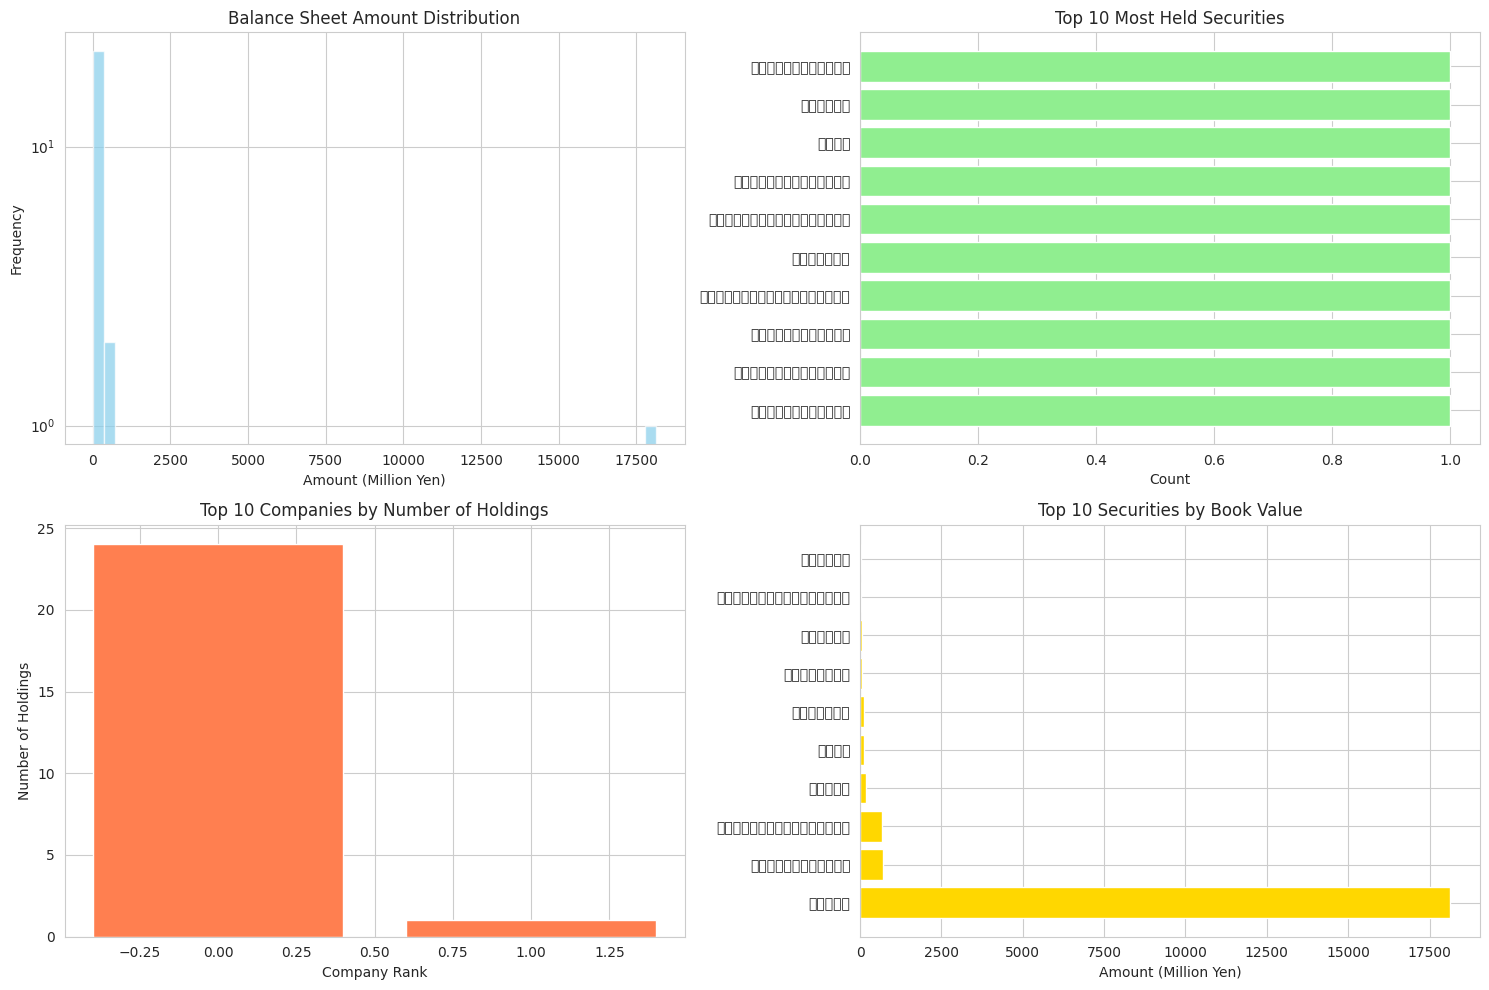

In [9]:
if not df.empty:
    # 図のサイズ設定
    plt.figure(figsize=(15, 10))
    
    # 1. 貸借対照表計上額の分布
    plt.subplot(2, 2, 1)
    plt.hist(df['book_value_million_yen'], bins=50, alpha=0.7, color='skyblue')
    plt.title('Balance Sheet Amount Distribution')
    plt.xlabel('Amount (Million Yen)')
    plt.ylabel('Frequency')
    plt.yscale('log')
    
    # 2. 上位保有銘柄
    plt.subplot(2, 2, 2)
    top_10_securities = df['held_security_name'].value_counts().head(10)
    plt.barh(range(len(top_10_securities)), top_10_securities.values, color='lightgreen')
    plt.yticks(range(len(top_10_securities)), top_10_securities.index)
    plt.title('Top 10 Most Held Securities')
    plt.xlabel('Count')
    
    # 3. 提出会社別の保有銘柄数
    plt.subplot(2, 2, 3)
    company_counts = df['filing_company_code'].value_counts().head(10)
    plt.bar(range(len(company_counts)), company_counts.values, color='coral')
    plt.title('Top 10 Companies by Number of Holdings')
    plt.xlabel('Company Rank')
    plt.ylabel('Number of Holdings')
    
    # 4. 貸借対照表計上額の上位銘柄
    plt.subplot(2, 2, 4)
    top_values = df.nlargest(10, 'book_value_million_yen')
    plt.barh(range(len(top_values)), top_values['book_value_million_yen'], color='gold')
    plt.yticks(range(len(top_values)), top_values['held_security_name'])
    plt.title('Top 10 Securities by Book Value')
    plt.xlabel('Amount (Million Yen)')
    
    plt.tight_layout()
    plt.show()
else:
    print("グラフ表示用のデータがありません。")

## 9. CSVファイルに保存

In [10]:
# CSVファイルに保存
if not df.empty:
    success = extractor.save_to_csv(OUTPUT_CSV)
    if success:
        print(f"\n保存されたファイル: {OUTPUT_CSV}")
        print(f"ファイルサイズ: {os.path.getsize(OUTPUT_CSV) / 1024:.2f} KB")
else:
    print("保存するデータがありません。")

データを保存しました: marketable_securities_analysis.csv
総レコード数: 25

保存されたファイル: marketable_securities_analysis.csv
ファイルサイズ: 8.25 KB


## 10. 全データ処理（オプション）

In [ ]:
# 注意: 全データ処理は時間がかかります。必要に応じて実行してください。

PROCESS_ALL = True  # Trueにすると全データを処理
BATCH_SIZE = 50      # バッチサイズ

if PROCESS_ALL:
    print("全データ処理を開始します...")
    
    # 新しい抽出器を初期化
    full_extractor = MarketableSecuritiesExtractor(XBRL_FOLDER_PATH, DOWNLOADS_PATH)
    
    # バッチ処理
    for i in range(0, len(folders), BATCH_SIZE):
        batch_folders = folders[i:i+BATCH_SIZE]
        
        print(f"\nバッチ {i//BATCH_SIZE + 1}: {len(batch_folders)} フォルダを処理")
        
        for j, folder in enumerate(batch_folders):
            print(f"  処理中 {j+1}/{len(batch_folders)}: {folder}")
            folder_path = os.path.join(XBRL_FOLDER_PATH, folder)
            full_extractor.process_xbrl_folder(folder_path)
            
            # 進捗表示
            if (j + 1) % 10 == 0:
                print(f"    → 現在の抽出データ: {len(full_extractor.results)} 件")
        
        # バッチ完了時に中間保存
        if len(full_extractor.results) > 0:
            interim_filename = f"interim_batch_{i//BATCH_SIZE + 1}.csv"
            full_extractor.save_to_csv(interim_filename)
            print(f"中間ファイル保存: {interim_filename}")
        
        # APIレート制限を考慮して休憩
        if i + BATCH_SIZE < len(folders):
            print("API制限を考慮して30秒休憩...")
            time.sleep(30)
    
    # 最終結果を保存
    final_df = full_extractor.to_dataframe()
    if not final_df.empty:
        final_filename = "full_marketable_securities_analysis.csv"
        full_extractor.save_to_csv(final_filename)
        
        print(f"\n=== 全データ処理完了 ===")
        print(f"処理済みフォルダ: {full_extractor.processed_count}")
        print(f"エラーフォルダ: {full_extractor.error_count}")
        print(f"総抽出データ件数: {len(final_df)}")
        print(f"最終ファイル: {final_filename}")
else:
    print("全データ処理はスキップされました。")
    print("全データを処理する場合は、PROCESS_ALL = True に設定してください。")

全データ処理を開始します...
EDINETコードマップを読み込みました: 11046 企業

バッチ 1: 50 フォルダを処理
  処理中 1/50: S100VI7P
EDINETコード E35535 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 2/50: S100TPJS
EDINETコード E02840 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 3/50: S100TPLJ
EDINETコード E36398 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 4/50: S100W926
EDINETコード E02917 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 5/50: S100UZ28
EDINETコード E05233 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 6/50: S100W2G3
EDINETコード E03641 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 7/50: S100W11V
EDINETコード E01636 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 8/50: S100W328
EDINETコード E37145 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 9/50: S100TWPK
EDINETコード E03472 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 10/50: S100TSPV
EDINETコード E02740 の情報取得エラー: 'ＥＤＩＮＥＴコード'
    → 現在の抽出データ: 60 件
  処理中 11/50: S100TTJN
EDINETコード E01518 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 12/50: S100TW3C
EDINETコード E02046 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 13/50: S100W3Q0
EDINETコード E00953 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 14/50: S100VG8G
EDINETコード E02978 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 15/50: S100VZ0S
EDINETコード E04990 の情報取得エラー: 'ＥＤＩＮＥＴコード'
  処理中 1

## 11. 結果サマリー

In [ ]:
print("=== 処理結果サマリー ===")
print(f"処理済みフォルダ数: {extractor.processed_count}")
print(f"エラーフォルダ数: {extractor.error_count}")
print(f"抽出データ件数: {len(extractor.results)}")

if not df.empty:
    print(f"\n=== データ統計 ===")
    print(f"提出会社数: {df['filing_company_code'].nunique()}")
    print(f"保有銘柄数: {df['held_security_name'].nunique()}")
    print(f"株式コード取得済み: {df['held_stock_code'].notna().sum()}")
    print(f"平均貸借対照表計上額: {df['book_value_million_yen'].mean():.2f} 百万円")
    print(f"最大貸借対照表計上額: {df['book_value_million_yen'].max():.2f} 百万円")
    
    print(f"\n=== 出力ファイル ===")
    if os.path.exists(OUTPUT_CSV):
        print(f"ファイル名: {OUTPUT_CSV}")
        print(f"ファイルサイズ: {os.path.getsize(OUTPUT_CSV) / 1024:.2f} KB")
        print(f"作成日時: {datetime.fromtimestamp(os.path.getmtime(OUTPUT_CSV))}")

print("\n処理が完了しました。")